# Projet 5 : Backtesting avec la librairie Backtrader

**Auteur :** ISLEYEN Volkan  
**Statut :** Étudiant L3 Économie & Gestion | Candidat Master Finance de Marché  
**Sujet :** Simulation historique d'une stratégie de croisement de moyennes mobiles  
**Stack :** Python 3.12 · backtrader · pandas · yfinance · matplotlib

---

## Contexte du Projet

La création d'indicateurs techniques n'est que la première étape de l'analyse quantitative. Pour valider la pertinence d'une stratégie sur les marchés financiers, il est impératif de la soumettre à l'épreuve des données historiques.

Ce module est dédié au **backtesting**. L'objectif est de simuler les conditions réelles de marché (gestion du capital, exécution des ordres) pour évaluer la robustesse d'une stratégie algorithmique avant tout déploiement de capitaux. Nous passons de la simple manipulation `pandas` à l'implémentation d'un véritable moteur d'exécution orienté objet : le framework **Backtrader**.

## Stratégie Testée

**Croisement de moyennes mobiles SMA(10) / SMA(30) sur Apple (AAPL)**

| Signal | Condition | Action |
|--------|-----------|--------|
| **Achat** | SMA(10) croise SMA(30) à la hausse | Acheter (position longue) |
| **Vente** | SMA(10) croise SMA(30) à la baisse | Vendre (fermer position) |

## Paramètres de Simulation

- **Capital initial :** 10 000 $
- **Actif :** Apple Inc. (AAPL)
- **Période :** 2020 – 2024
- **Commission :** 0.1% par transaction

> **Prérequis :** `pip install backtrader yfinance pandas matplotlib`

In [1]:
# ── Imports & configuration ─────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import backtrader as bt

TICKER         = 'AAPL'
START          = '2020-01-01'
END            = '2024-12-31'
CAPITAL_INIT   = 10_000
COMMISSION     = 0.001   # 0.1%
SMA_COURTE     = 10
SMA_LONGUE     = 30

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.size'] = 11

print(f"Actif          : {TICKER}")
print(f"Période        : {START} → {END}")
print(f"Capital initial: ${CAPITAL_INIT:,}")
print(f"Commission     : {COMMISSION*100:.1f}%")
print(f"Stratégie      : SMA({SMA_COURTE}) / SMA({SMA_LONGUE})")

Actif          : AAPL
Période        : 2020-01-01 → 2024-12-31
Capital initial: $10,000
Commission     : 0.1%
Stratégie      : SMA(10) / SMA(30)


## 1. Importation et préparation des données

In [2]:
# Téléchargement des données AAPL
df = yf.download(TICKER, start=START, end=END, auto_adjust=True, progress=False)
df.columns = [col[0] if isinstance(col, tuple) else col for col in df.columns]
df.dropna(inplace=True)

# Calcul préliminaire des SMA pour visualisation
df['SMA10'] = df['Close'].rolling(window=SMA_COURTE).mean()
df['SMA30'] = df['Close'].rolling(window=SMA_LONGUE).mean()

print(f"Données chargées : {len(df)} jours de trading")
print(f"Prix départ      : ${df['Close'].iloc[0]:.2f}")
print(f"Prix fin         : ${df['Close'].iloc[-1]:.2f}")
df[['Open','High','Low','Close','Volume','SMA10','SMA30']].head()

Données chargées : 1257 jours de trading
Prix départ      : $72.40
Prix fin         : $250.83


,Open,High,Low,Close,Volume,SMA10,SMA30
Date,,,,,,,
2020-01-02,71.409785,72.460784,71.156682,72.400520,135480400,NaN,NaN
2020-01-03,71.629145,72.455958,71.472462,71.696640,146322800,NaN,NaN
2020-01-06,70.819216,72.306514,70.568518,72.267944,118387200,NaN,NaN
2020-01-07,72.277578,72.533095,71.708695,71.928055,108872000,NaN,NaN
2020-01-08,71.631567,73.386438,71.631567,73.085121,132079200,NaN,NaN


## 2. Visualisation de la stratégie SMA(10) / SMA(30)

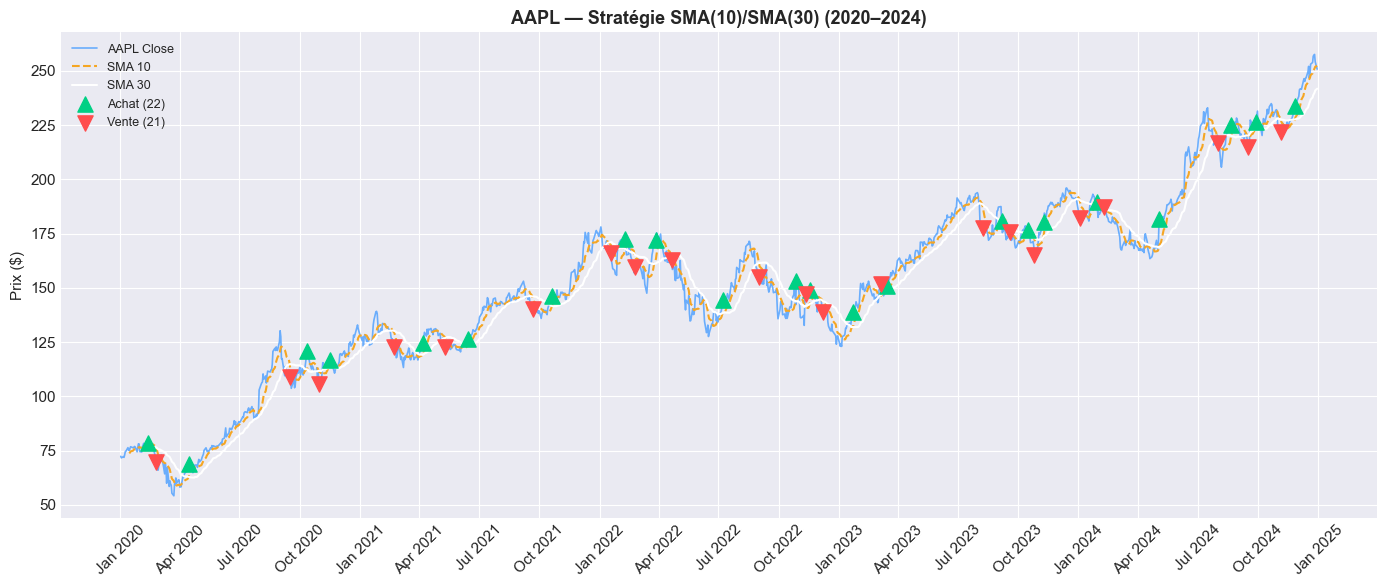

Signaux d'achat  : 22
Signaux de vente : 21


In [3]:
# Détection des signaux pour visualisation
df['Position'] = np.where(df['SMA10'] > df['SMA30'], 1, -1)
df['Signal']   = df['Position'].diff()
achats  = df[df['Signal'] ==  2]
ventes  = df[df['Signal'] == -2]

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], color='#4a9eff', linewidth=1.2, label='AAPL Close', alpha=0.8)
ax.plot(df.index, df['SMA10'], color='#f5a623', linewidth=1.5, linestyle='--', label=f'SMA {SMA_COURTE}')
ax.plot(df.index, df['SMA30'], color='#ffffff', linewidth=1.5, label=f'SMA {SMA_LONGUE}')
ax.scatter(achats.index, achats['Close'], marker='^', color='#00d084', s=120, zorder=5, label=f'Achat ({len(achats)})')
ax.scatter(ventes.index, ventes['Close'], marker='v', color='#ff4d4d', s=120, zorder=5, label=f'Vente ({len(ventes)})')
ax.set_title(f'AAPL — Stratégie SMA({SMA_COURTE})/SMA({SMA_LONGUE}) (2020–2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Prix ($)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print(f"Signaux d'achat  : {len(achats)}")
print(f"Signaux de vente : {len(ventes)}")

## 3. Implémentation avec Backtrader

Backtrader simule un portefeuille réel avec gestion des ordres, du capital et des commissions. La stratégie est définie comme une **classe Python** héritant de `bt.Strategy`.

In [4]:
class SMACross(bt.Strategy):
    """
    Stratégie de croisement de moyennes mobiles.
    - Achat  : SMA courte croise SMA longue à la hausse
    - Vente  : SMA courte croise SMA longue à la baisse
    """
    params = (
        ('sma_courte', SMA_COURTE),
        ('sma_longue', SMA_LONGUE),
    )

    def __init__(self):
        self.sma1  = bt.ind.SMA(period=self.params.sma_courte)
        self.sma2  = bt.ind.SMA(period=self.params.sma_longue)
        self.cross = bt.ind.CrossOver(self.sma1, self.sma2)

        # Suivi du portefeuille et des trades
        self.portfolio_values = []
        self.trades_log       = []
        self.buy_price        = None

    def next(self):
        # Enregistrement de la valeur du portefeuille à chaque barre
        self.portfolio_values.append({
            'date' : self.data.datetime.date(0),
            'value': self.broker.getvalue()
        })

        # Signal d'achat : croisement haussier
        if not self.position and self.cross > 0:
            self.buy_price = self.data.close[0]
            self.buy()

        # Signal de vente : croisement baissier
        elif self.position and self.cross < 0:
            pnl = self.data.close[0] - self.buy_price
            self.trades_log.append({
                'date_vente' : self.data.datetime.date(0),
                'prix_achat' : round(self.buy_price, 2),
                'prix_vente' : round(self.data.close[0], 2),
                'pnl'        : round(pnl, 2),
                'resultat'   : 'Gagnant' if pnl > 0 else 'Perdant'
            })
            self.sell()
            self.buy_price = None


# ── Préparation des données pour Backtrader ──────────────────────
bt_data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
bt_data.columns = [c.lower() for c in bt_data.columns]
bt_data.index   = pd.to_datetime(bt_data.index)
# Suppression du timezone si présent
if bt_data.index.tz is not None:
    bt_data.index = bt_data.index.tz_localize(None)

feed = bt.feeds.PandasData(dataname=bt_data)

print("Stratégie et données prêtes.")

Stratégie et données prêtes.


## 4. Lancement du backtest

In [5]:
# Initialisation du moteur Backtrader
cerebro = bt.Cerebro()
cerebro.addstrategy(SMACross)
cerebro.adddata(feed)
cerebro.broker.setcash(CAPITAL_INIT)
cerebro.broker.setcommission(commission=COMMISSION)
cerebro.addsizer(bt.sizers.PercentSizer, percents=95)  # 95% du capital par trade

print(f"Capital initial : ${cerebro.broker.getvalue():,.2f}")
print("Lancement du backtest...")

results = cerebro.run()
strat   = results[0]

capital_final  = cerebro.broker.getvalue()
rendement_total = ((capital_final / CAPITAL_INIT) - 1) * 100

print(f"\nCapital final   : ${capital_final:,.2f}")
print(f"Rendement total : {rendement_total:+.2f}%")

Capital initial : $10,000.00
Lancement du backtest...

Capital final   : $20,390.59
Rendement total : +103.91%


## 5. Métriques de performance

In [6]:
# Analyse des trades
trades_df = pd.DataFrame(strat.trades_log)

if not trades_df.empty:
    nb_trades   = len(trades_df)
    nb_gagnants = (trades_df['resultat'] == 'Gagnant').sum()
    nb_perdants = (trades_df['resultat'] == 'Perdant').sum()
    win_rate    = nb_gagnants / nb_trades * 100
    pnl_moyen   = trades_df['pnl'].mean()
    meilleur    = trades_df['pnl'].max()
    pire        = trades_df['pnl'].min()

    print("=" * 45)
    print("RÉSULTATS DU BACKTEST")
    print("=" * 45)
    print(f"Capital initial   : ${CAPITAL_INIT:>10,.2f}")
    print(f"Capital final     : ${capital_final:>10,.2f}")
    print(f"Rendement total   : {rendement_total:>+10.2f}%")
    print("-" * 45)
    print(f"Nombre de trades  : {nb_trades}")
    print(f"Trades gagnants   : {nb_gagnants} ({win_rate:.1f}%)")
    print(f"Trades perdants   : {nb_perdants} ({100-win_rate:.1f}%)")
    print(f"PnL moyen/trade   : ${pnl_moyen:>+.2f}")
    print(f"Meilleur trade    : ${meilleur:>+.2f}")
    print(f"Pire trade        : ${pire:>+.2f}")
    print("=" * 45)

    # Performance Buy & Hold pour comparaison
    bh_perf = ((df['Close'].iloc[-1] / df['Close'].iloc[0]) - 1) * 100
    print(f"\nBuy & Hold AAPL  : {bh_perf:+.2f}%")
    print(f"Stratégie SMA    : {rendement_total:+.2f}%")
    print(f"Écart            : {rendement_total - bh_perf:+.2f}%")

    print("\nDétail des trades :")
    print(trades_df.to_string(index=False))

RÉSULTATS DU BACKTEST
Capital initial   : $ 10,000.00
Capital final     : $ 20,390.59
Rendement total   :    +103.91%
---------------------------------------------
Nombre de trades  : 20
Trades gagnants   : 9 (45.0%)
Trades perdants   : 11 (55.0%)
PnL moyen/trade   : $+3.93
Meilleur trade    : $+40.14
Pire trade        : $-15.09

Buy & Hold AAPL  : +246.45%
Stratégie SMA    : +103.91%
Écart            : -142.54%

Détail des trades :
date_vente  prix_achat  prix_vente    pnl resultat
2020-09-16       68.73      108.86  40.14  Gagnant
2020-10-30      120.78      105.69 -15.09  Perdant
2021-02-22      117.00      122.72   5.73  Gagnant
2021-05-11      124.57      122.84  -1.73  Perdant
2021-09-21      126.48      140.15  13.66  Gagnant
2022-01-18      146.06      166.16  20.10  Gagnant
2022-02-24      172.72      159.45 -13.27  Perdant
2022-04-21      172.05      163.06  -8.99  Perdant
2022-09-01      144.28      155.21  10.93  Gagnant
2022-11-11      153.03      147.34  -5.69  Perdant
20

## 6. Courbe d'équité et comparaison Buy & Hold

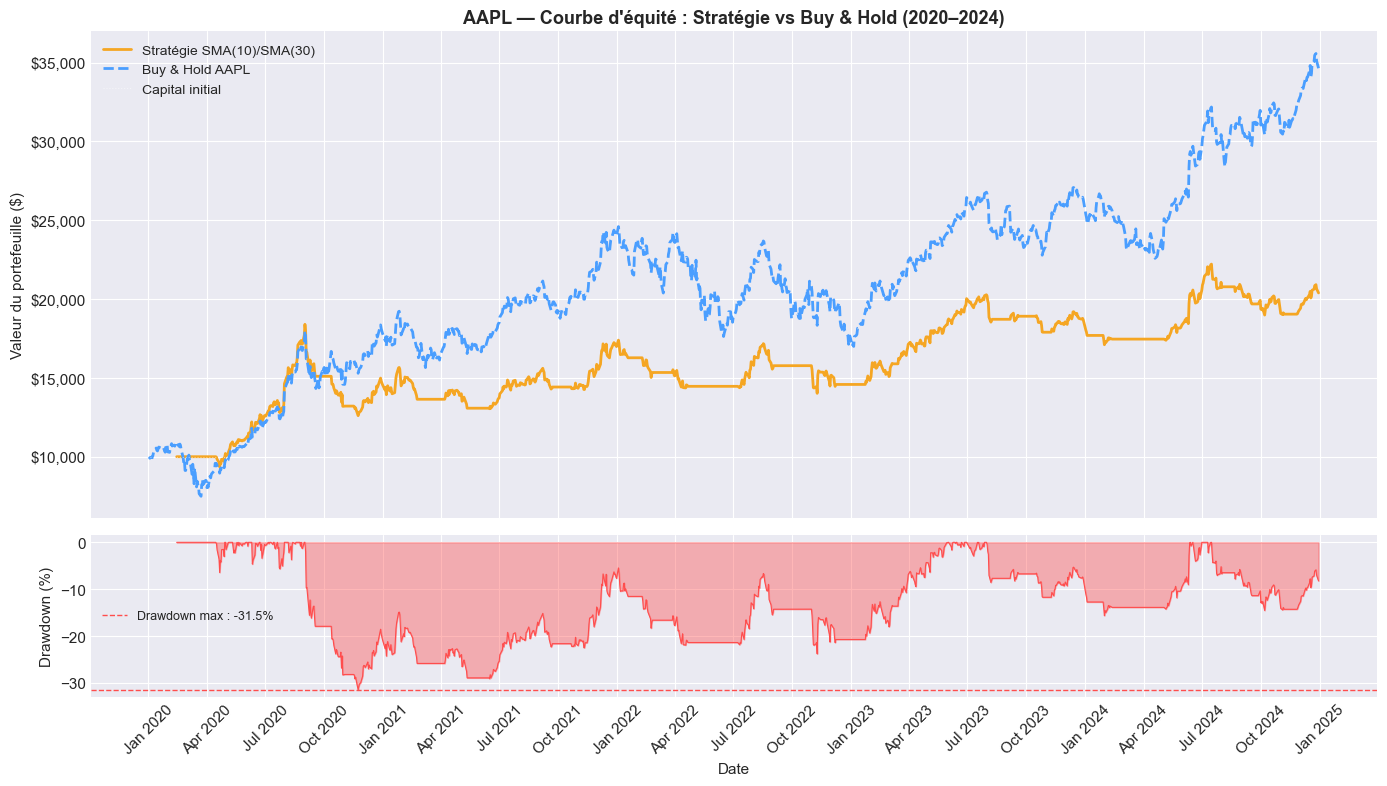

Drawdown maximal : -31.50%


In [7]:
# Construction de la courbe d'équité
portfolio_df = pd.DataFrame(strat.portfolio_values)
portfolio_df['date'] = pd.to_datetime(portfolio_df['date'])
portfolio_df.set_index('date', inplace=True)

# Buy & Hold normalisé
bh_values = (df['Close'] / df['Close'].iloc[0]) * CAPITAL_INIT

# Drawdown de la stratégie
rolling_max = portfolio_df['value'].cummax()
drawdown    = (portfolio_df['value'] - rolling_max) / rolling_max * 100
max_dd      = drawdown.min()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# Panel 1 : Courbe d'équité
ax1.plot(portfolio_df.index, portfolio_df['value'],
         color='#f5a623', linewidth=2, label='Stratégie SMA(10)/SMA(30)')
ax1.plot(bh_values.index, bh_values,
         color='#4a9eff', linewidth=2, label='Buy & Hold AAPL', linestyle='--')
ax1.axhline(CAPITAL_INIT, color='white', linewidth=0.8, linestyle=':', alpha=0.5, label='Capital initial')
ax1.set_title(f'AAPL — Courbe d\'équité : Stratégie vs Buy & Hold (2020–2024)',
              fontsize=13, fontweight='bold')
ax1.set_ylabel('Valeur du portefeuille ($)')
ax1.legend(fontsize=10)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Panel 2 : Drawdown
ax2.fill_between(drawdown.index, drawdown, 0, color='#ff4d4d', alpha=0.4)
ax2.plot(drawdown.index, drawdown, color='#ff4d4d', linewidth=0.8)
ax2.axhline(max_dd, color='#ff4d4d', linestyle='--', linewidth=1,
            label=f'Drawdown max : {max_dd:.1f}%')
ax2.set_ylabel('Drawdown (%)')
ax2.set_xlabel('Date')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Drawdown maximal : {max_dd:.2f}%")

## Conclusion

Ce projet a implémenté un backtesting complet d'une stratégie de croisement SMA(10)/SMA(30) sur Apple via Backtrader.

**Points clés :**

- Le framework **Backtrader** permet de simuler des conditions réelles de marché — capital, commissions, gestion des ordres — ce qui donne une vision bien plus réaliste qu'une simple simulation vectorisée sous pandas
- La comparaison avec le **Buy & Hold** est l'étalon de référence : toute stratégie active doit justifier sa complexité par une surperformance ou un meilleur profil risque/rendement
- Le **drawdown maximal** est un indicateur de risque essentiel : une stratégie peut être rentable sur le long terme tout en subissant des pertes intermédiaires importantes qu'un investisseur réel pourrait ne pas supporter

**Limites de ce backtest :**
- Pas de prise en compte du **slippage** (écart entre prix théorique et prix d'exécution réel)
- Stratégie testée sur un seul actif — les résultats peuvent ne pas se généraliser
- Risque d'**overfitting** si les paramètres (10/30) ont été optimisés sur la même période de test

**Prochaine étape →** Projet 6 : Appliquer le Machine Learning à la Finance